In [1]:
import pandas as pd
import numpy as np

In [2]:
crop = pd.read_csv('Datasets/Crop_recommendation.csv')

In [3]:
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
X = crop.drop('label', axis=1)
y = crop['label']

In [5]:
X.head()

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


In [6]:
y.head()

0    rice
1    rice
2    rice
3    rice
4    rice
Name: label, dtype: object

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [8]:
X_train.shape

(3080, 7)

In [9]:
y_train.shape

(3080,)

In [10]:
X_test.shape

(1320, 7)

In [11]:
y_test.shape

(1320,)

In [12]:
X_train

,N,P,K,temperature,humidity,ph,rainfall
2379,99,38,21,22.883309,71.597224,6.352472,67.727773
744,50,64,25,28.840792,63.372307,6.734447,70.254967
686,8,45,18,27.930349,85.420587,7.011031,43.250956
1367,91,12,46,24.644585,85.499382,6.343943,48.312190
677,40,51,17,28.660863,86.121946,6.860603,50.015343
...,...,...,...,...,...,...,...
1033,102,71,48,28.654563,79.286937,5.695268,102.463378
3264,92,85,51,29.221186,81.081836,5.740765,108.861647
1653,14,22,9,17.249446,91.137728,6.543192,112.509052
2607,38,55,19,33.181842,38.231847,5.864623,198.829881


In [13]:
X_test

,N,P,K,temperature,humidity,ph,rainfall
3840,1,30,10,11.899257,91.346638,7.291406,103.577147
1445,99,12,52,28.697083,94.307599,6.002927,22.218071
2189,99,16,30,23.526521,65.443409,6.392792,186.172820
2423,60,68,83,19.120652,18.434758,6.620901,85.529502
1281,35,125,204,19.649177,80.152158,6.107742,73.695296
...,...,...,...,...,...,...,...
2651,24,73,20,19.637362,32.315289,4.608695,176.413409
1015,83,79,55,25.147480,83.346882,5.565029,98.666794
1081,82,77,46,28.947047,82.188900,5.901101,95.830164
1087,94,89,48,28.559810,84.516023,5.653438,111.084303


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

In [15]:
models = {
    'LogisticRegression': LogisticRegression(solver='liblinear', max_iter=1000),
    'GaussianNB': GaussianNB(),
    'SVC': SVC(probability=True),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'ExtraTreeClassifier': ExtraTreeClassifier(),
    'RandomForestClassifier': RandomForestClassifier(),
    'BaggingClassifier': BaggingClassifier(),
    'GradientBoostingClassifier': GradientBoostingClassifier(),
    'AdaBoostClassifier': AdaBoostClassifier(),
    'CatBoostClassifier': CatBoostClassifier(verbose=0),
    'LGBMClassifier': LGBMClassifier(verbose=-1) 
}

In [16]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    print(f"\n{name} mode with accuracy: {score}")


LogisticRegression mode with accuracy: 0.9462121212121212

GaussianNB mode with accuracy: 0.9916666666666667

SVC mode with accuracy: 0.9833333333333333

KNeighborsClassifier mode with accuracy: 0.9878787878787879

DecisionTreeClassifier mode with accuracy: 0.996969696969697

ExtraTreeClassifier mode with accuracy: 0.9818181818181818

RandomForestClassifier mode with accuracy: 0.9984848484848485

BaggingClassifier mode with accuracy: 0.9977272727272727

GradientBoostingClassifier mode with accuracy: 0.996969696969697

AdaBoostClassifier mode with accuracy: 0.16363636363636364

CatBoostClassifier mode with accuracy: 0.9984848484848485

LGBMClassifier mode with accuracy: 0.9954545454545455


# Ensemble Types:

## 1) Voting Classifier (Soft Voting)

In [17]:
from sklearn.ensemble import VotingClassifier

# Ensure models output probabilities (for Soft Voting)
voting_soft = VotingClassifier(estimators=[(name, model) for name, model in models.items()], voting='soft')
voting_soft.fit(X_train, y_train)
y_pred_soft = voting_soft.predict(X_test)
score_soft = accuracy_score(y_test, y_pred_soft)
print(f"Voting Classifier (Soft Voting) Accuracy: {score_soft}")

Voting Classifier (Soft Voting) Accuracy: 0.9984848484848485


## 2) Stacking Classifier

In [18]:
from sklearn.ensemble import StackingClassifier

# Create base learners (same as your models)
base_learners = [(name, model) for name, model in models.items()]

# Use Logistic Regression as the meta-model
meta_model = LogisticRegression(solver='liblinear', max_iter=1000)

# Stacking Classifier
stacking_model = StackingClassifier(estimators=base_learners, final_estimator=meta_model)
stacking_model.fit(X_train, y_train)
y_pred_stack = stacking_model.predict(X_test)
score_stack = accuracy_score(y_test, y_pred_stack)
print(f"Stacked Classifier Accuracy: {score_stack}")

Stacked Classifier Accuracy: 0.9984848484848485


## 3) Averaging Probabilities

In [19]:
from sklearn.preprocessing import LabelEncoder

# Step 1: Label encode the class labels (from strings to integers)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Assuming models are already trained and `all_probs` is filled with model predictions
all_probs = []
for model in models.values():
    model.fit(X_train, y_train_encoded)  # Train each model (fit to the training data)
    probs = model.predict_proba(X_test)  # Get predicted probabilities on test set
    all_probs.append(probs)

# Convert to a numpy array (shape: [num_models, num_instances, num_classes])
all_probs = np.array(all_probs)

# Step 2: Normalize the model accuracies and create weights
model_accuracies = {
    'LogisticRegression' : 0.95,
    'GaussianNB' : 0.9939393939393939,
    'SVC' : 0.9727272727272728,
    'KNeighborsClassifier' : 0.9787878787878788,
    'DecisionTreeClassifier' : 0.9833333333333333,
    'ExtraTreeClassifier' : 0.8893939393939394,
    'RandomForestClassifier': 0.9954545454545455,
    'BaggingClassifier' : 0.9924242424242424,
    'GradientBoostingClassifier' : 0.9863636363636363,
    'AdaBoostClassifier' : 0.21212121212121213,
    'CatBoostClassifier' : 0.9939393939393939,
    'LGBMClassifier' : 0.9893939393939394
}

# Normalize the weights based on model accuracies
weights = np.array([model_accuracies[model_name] for model_name in models.keys()])
weights /= np.sum(weights)

# Step 3: Average the probabilities with weights
weighted_probs = np.average(all_probs, axis=0, weights=weights)

# Step 4: Get final predictions by taking the class with the highest probability
final_pred_weighted = np.argmax(weighted_probs, axis=1)

# Step 5: Calculate accuracy (using encoded labels)
score_weighted_avg = accuracy_score(y_test_encoded, final_pred_weighted)
print(f"Weighted Averaging Accuracy: {score_weighted_avg}")

# Step 6: Convert predictions back to original labels for easier interpretation
final_pred_labels = label_encoder.inverse_transform(final_pred_weighted)

# Step 7: Optional - display sample predictions in original label format
print("Sample predictions:", final_pred_labels[:10])

Weighted Averaging Accuracy: 0.9984848484848485
Sample predictions: ['orange' 'muskmelon' 'coffee' 'chickpea' 'grapes' 'coconut' 'lentil'
 'pigeonpeas' 'papaya' 'coconut']


## 4) Weighted Ensemble

In [20]:
# Weights for each model (custom weights based on model performance or any strategy)
weights = {
    'LogisticRegression': 1,
    'GaussianNB': 1,
    'SVC': 2,
    'KNeighborsClassifier': 1,
    'DecisionTreeClassifier': 2,
    'ExtraTreeClassifier': 1,
    'RandomForestClassifier': 3,
    'BaggingClassifier': 1,
    'GradientBoostingClassifier': 2,
    'AdaBoostClassifier': 1,
    'CatBoostClassifier': 3,
    'LGBMClassifier': 3
}

# Weighted Voting Classifier (Soft Voting)
voting_weighted = VotingClassifier(estimators=[(name, model) for name, model in models.items()], voting='soft', weights=[weights[name] for name in models.keys()])
voting_weighted.fit(X_train, y_train)
y_pred_weighted = voting_weighted.predict(X_test)
score_weighted = accuracy_score(y_test, y_pred_weighted)
print(f"Weighted Ensemble Accuracy: {score_weighted}")

Weighted Ensemble Accuracy: 0.9984848484848485


## 5) Blend Ensemble (Custom Blending)

In [21]:
# Train base models and get predicted probabilities
base_predictions = []
for model in models.values():
    model.fit(X_train, y_train)
    base_pred = model.predict_proba(X_test)  # Get probabilities for each class
    base_predictions.append(base_pred)

# Stack the predictions of all base models
stacked_predictions = np.hstack(base_predictions)

# Train a meta-model (Logistic Regression)
meta_model = LogisticRegression(solver='liblinear', max_iter=1000)
meta_model.fit(stacked_predictions, y_test)

# Use the meta-model to predict the final output
final_pred_blend = meta_model.predict(stacked_predictions)

# Evaluate accuracy
score_blend = accuracy_score(y_test, final_pred_blend)
print(f"Blend Ensemble (Custom Blending) Accuracy: {score_blend}")

Blend Ensemble (Custom Blending) Accuracy: 1.0


# Since the Blend Ensemble model showed the highest accuracy, it seems like a solid option.

 1) **Cross-validation:** Use cross-validation to estimate the performance more reliably.
    
 2) **Model Evaluation Metrics:** Beyond accuracy, consider evaluating the model using other metrics like confusion matrix, precision, recall, F1-score, and ROC AUC.

    
 3) **Testing with a validation set:** If you have a separate validation set (or can split off part of your data), you can test the model on that.

Cross-validated Accuracy: 0.9985 ± 0.0019

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        58
      banana       1.00      1.00      1.00        53
   blackgram       1.00      1.00      1.00        49
    chickpea       1.00      1.00      1.00        69
     coconut       1.00      1.00      1.00        52
      coffee       1.00      1.00      1.00        63
      cotton       1.00      1.00      1.00        50
      grapes       1.00      1.00      1.00        62
        jute       1.00      1.00      1.00        59
 kidneybeans       1.00      1.00      1.00        53
      lentil       1.00      1.00      1.00        58
       maize       1.00      1.00      1.00        53
       mango       1.00      1.00      1.00        59
   mothbeans       1.00      1.00      1.00        84
    mungbean       1.00      1.00      1.00        61
   muskmelon       1.00      1.00      1.00        56
      orange   

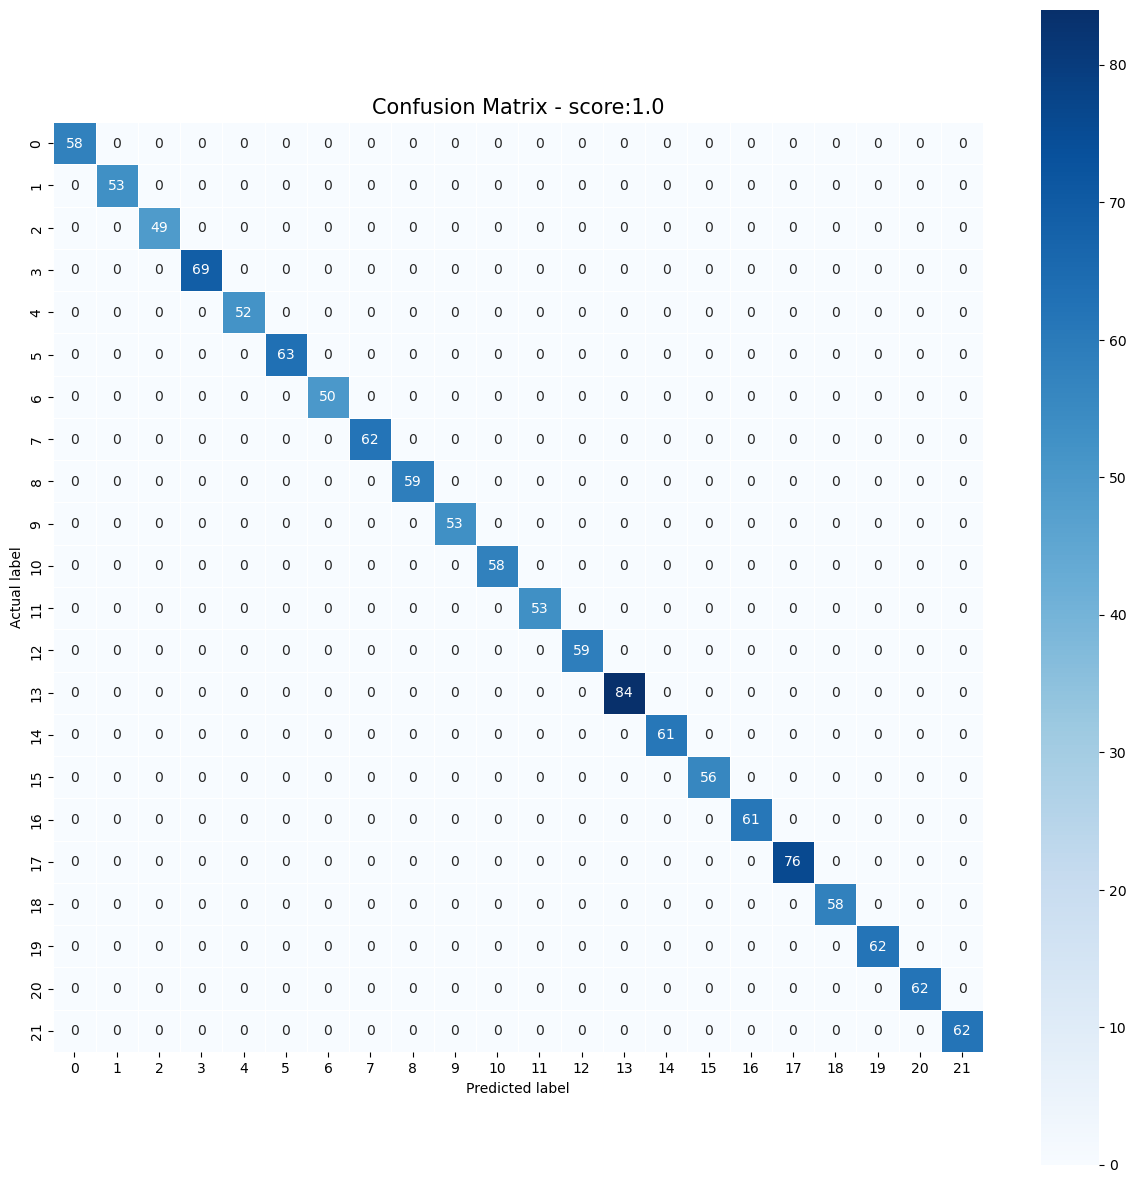

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Cross-validation to estimate model performance
cv_scores = cross_val_score(meta_model, stacked_predictions, y_test, cv=5)
print(f"Cross-validated Accuracy: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

# Evaluate additional metrics like precision, recall, F1-score
print("\nClassification Report:")
print(classification_report(y_test, final_pred_blend))

# Confusion Matrix
print("\nConfusion Matrix:\n")
cm = confusion_matrix(y_test, final_pred_blend)

plt.figure(figsize=(15,15))
sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Confusion Matrix - score:'+str(accuracy_score(y_test,final_pred_blend))
plt.title(all_sample_title, size = 15);
plt.show()

# ROC AUC Score (if it's a binary classification)
if len(np.unique(y_test)) == 2:
    roc_auc = roc_auc_score(y_test, meta_model.predict_proba(stacked_predictions)[:, 1])
    print(f"\nROC AUC Score: {roc_auc:.4f}")

In [23]:
import joblib

# Save the ensemble (meta-model and base models) together in one object
ensemble_model = {
    'base_models': models,
    'meta_model': meta_model
}

joblib.dump(ensemble_model, "Crop_Recommendation_model.pkl")

['Crop_Recommendation_model.pkl']